In [2]:
import sys

print(sys.executable)
print(sys.version)

/mnt/d/COLLEGE/SEM5/MLOPs/mlops-assignments/Assignment-2/.venv/bin/python
3.14.4 (main, Jun 18 2026, 14:25:02) [GCC 15.2.0]


In [3]:
import mlflow

print("MLflow version:", mlflow.__version__)

MLflow version: 3.15.1


In [4]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df["target"].value_counts())

print("\nDataset Statistics:")
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Target Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64

Dataset Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [6]:
X = df.drop("target", axis=1)
y = df["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

Feature shape: (150, 4)
Target shape: (150,)

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


In [9]:
import mlflow

experiment_name = "Iris Classification - Hyperparameter Tracking"

mlflow.set_experiment(experiment_name)

print("MLflow experiment:", experiment_name)

2026/08/17 12:40:38 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/17 12:40:38 INFO mlflow.store.db.utils: Updating database tables
2026/08/17 12:40:48 INFO mlflow.tracking.fluent: Experiment with name 'Iris Classification - Hyperparameter Tracking' does not exist. Creating a new experiment.


MLflow experiment: Iris Classification - Hyperparameter Tracking


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

baseline_model = LogisticRegression(
    C=1.0,
    max_iter=100,
    random_state=42
)

baseline_model.fit(X_train_scaled, y_train)

baseline_predictions = baseline_model.predict(X_test_scaled)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print(f"Baseline accuracy: {baseline_accuracy:.4f}")

Baseline accuracy: 0.9333


In [11]:
with mlflow.start_run(run_name="Baseline Logistic Regression"):

   mlflow.log_param("model", "Logistic Regression")
   mlflow.log_param("C", 1.0)
   mlflow.log_param("max_iter", 100)
   mlflow.log_param("scaler", "StandardScaler")

   mlflow.log_metric("test_accuracy", baseline_accuracy)

   mlflow.sklearn.log_model(
      baseline_model,
      "model"
   )

   print(f"Logged baseline run with accuracy: {baseline_accuracy:.4f}")

2026/08/17 12:41:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged baseline run with accuracy: 0.9333


In [12]:
c_values = [0.1, 1.0, 10.0]

for c in c_values:
    model = LogisticRegression(
        C=c,
        max_iter=100,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, predictions)

    with mlflow.start_run(run_name=f"Logistic Regression - C={c}"):
        mlflow.log_param("model", "Logistic Regression")
        mlflow.log_param("C", c)
        mlflow.log_param("max_iter", 100)
        mlflow.log_param("scaler", "StandardScaler")
        mlflow.log_metric("test_accuracy", accuracy)

        mlflow.sklearn.log_model(
            model,
            name="model"
        )

    print(f"C = {c:<4} | Test Accuracy = {accuracy:.4f}")

C = 0.1  | Test Accuracy = 0.8667
C = 1.0  | Test Accuracy = 0.9333
C = 10.0 | Test Accuracy = 1.0000


In [13]:
max_iter_values = [50, 100, 200]

for max_iter in max_iter_values:
    model = LogisticRegression(
        C=1.0,
        max_iter=max_iter,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, predictions)

    with mlflow.start_run(run_name=f"Logistic Regression - max_iter={max_iter}"):
        mlflow.log_param("model", "Logistic Regression")
        mlflow.log_param("C", 1.0)
        mlflow.log_param("max_iter", max_iter)
        mlflow.log_param("scaler", "StandardScaler")
        mlflow.log_metric("test_accuracy", accuracy)

        mlflow.sklearn.log_model(
            model,
            name="model"
        )

    print(f"max_iter = {max_iter:<3} | Test Accuracy = {accuracy:.4f}")

max_iter = 50  | Test Accuracy = 0.9333
max_iter = 100 | Test Accuracy = 0.9333
max_iter = 200 | Test Accuracy = 0.9333


In [14]:
experiment = mlflow.get_experiment_by_name(experiment_name)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

print("Total runs:", len(runs))
print("\nTracked runs:")
print(
    runs[
        [
            "run_id",
            "tags.mlflow.runName",
            "params.C",
            "params.max_iter",
            "metrics.test_accuracy"
        ]
    ].to_string(index=False)
)

Total runs: 7

Tracked runs:
                          run_id                tags.mlflow.runName params.C params.max_iter  metrics.test_accuracy
69fa7e176adc473d869b63f28b605afd Logistic Regression - max_iter=200      1.0             200               0.933333
50992536cd2e4779bbac76270aea368c Logistic Regression - max_iter=100      1.0             100               0.933333
032cda226db04ebf856f32edd9eb73a9  Logistic Regression - max_iter=50      1.0              50               0.933333
c3fb6574c36b4a1faedbe41c82946496       Logistic Regression - C=10.0     10.0             100               1.000000
f5fcfef40fec46d3a342a969b03c76f4        Logistic Regression - C=1.0      1.0             100               0.933333
df90fff873c7415cb3f8f9b8848c8165        Logistic Regression - C=0.1      0.1             100               0.866667
5426008ef3d64979a344ed390cc2d5f1       Baseline Logistic Regression      1.0             100               0.933333


In [15]:
best_run = runs.loc[runs["metrics.test_accuracy"].idxmax()]

print("Best Run")
print("--------")
print("Run Name:", best_run["tags.mlflow.runName"])
print("C:", best_run["params.C"])
print("max_iter:", best_run["params.max_iter"])
print(f"Test Accuracy: {best_run['metrics.test_accuracy']:.4f}")

Best Run
--------
Run Name: Logistic Regression - C=10.0
C: 10.0
max_iter: 100
Test Accuracy: 1.0000


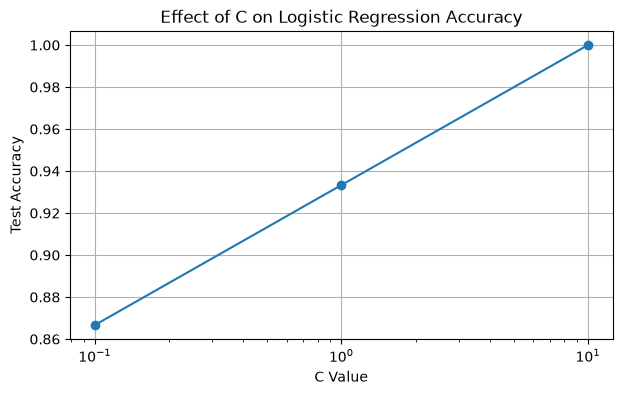

In [16]:
import matplotlib.pyplot as plt

c_results = runs[
    runs["tags.mlflow.runName"].str.startswith("Logistic Regression - C=")
].copy()

c_results["C"] = c_results["params.C"].astype(float)
c_results = c_results.sort_values("C")

plt.figure(figsize=(7, 4))
plt.plot(
    c_results["C"],
    c_results["metrics.test_accuracy"],
    marker="o"
)

plt.xscale("log")
plt.xlabel("C Value")
plt.ylabel("Test Accuracy")
plt.title("Effect of C on Logistic Regression Accuracy")
plt.grid(True)
plt.show()

In [17]:
best_model = LogisticRegression(
    C=10.0,
    max_iter=100,
    random_state=42
)

best_model.fit(X_train_scaled, y_train)

final_predictions = best_model.predict(X_test_scaled)
final_accuracy = accuracy_score(y_test, final_predictions)

print("Final Model: Logistic Regression")
print("C:", 10.0)
print("max_iter:", 100)
print(f"Final Test Accuracy: {final_accuracy:.4f}")
print(f"Correct Predictions: {(final_predictions == y_test).sum()} / {len(y_test)}")

Final Model: Logistic Regression
C: 10.0
max_iter: 100
Final Test Accuracy: 1.0000
Correct Predictions: 30 / 30


In [18]:
with mlflow.start_run(run_name="Final Best Model"):
    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("C", 10.0)
    mlflow.log_param("max_iter", 100)
    mlflow.log_param("scaler", "StandardScaler")
    mlflow.log_metric("test_accuracy", final_accuracy)

    mlflow.sklearn.log_model(
        best_model,
        name="final_model"
    )

    print("Final model logged successfully.")

Final model logged successfully.


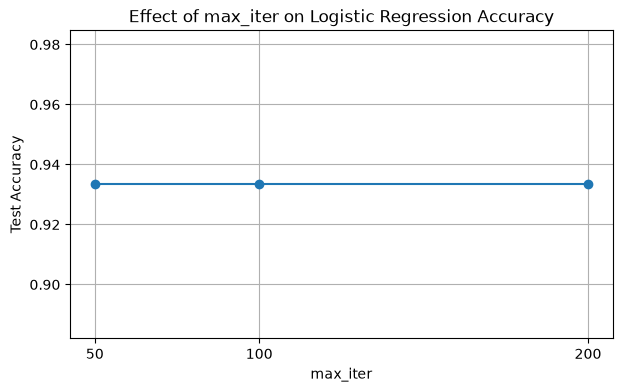

In [19]:
iter_results = runs[
    runs["tags.mlflow.runName"].str.startswith("Logistic Regression - max_iter=")
].copy()

iter_results["max_iter"] = iter_results["params.max_iter"].astype(int)
iter_results = iter_results.sort_values("max_iter")

plt.figure(figsize=(7, 4))
plt.plot(
    iter_results["max_iter"],
    iter_results["metrics.test_accuracy"],
    marker="o"
)

plt.xlabel("max_iter")
plt.ylabel("Test Accuracy")
plt.title("Effect of max_iter on Logistic Regression Accuracy")
plt.xticks([50, 100, 200])
plt.grid(True)
plt.show()

In [20]:
dataset = mlflow.data.from_pandas(
    df,
    source="sklearn.datasets.load_iris",
    name="iris_dataset",
    targets="target"
)

with mlflow.start_run(run_name="Iris Dataset Registration"):
    mlflow.log_input(
        dataset,
        context="iris-classification"
    )

print("Iris dataset registered with MLflow.")

/mnt/d/COLLEGE/SEM5/MLOPs/mlops-assignments/Assignment-2/.venv/lib/python3.14/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/mnt/d/COLLEGE/SEM5/MLOPs/mlops-assignments/Assignment-2/.venv/lib/python3.14/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may h

Iris dataset registered with MLflow.
